In [31]:
import numpy as np
T = 1.0       # Total time
N = 100       # Number of time steps
delta_t = T / N  # Time step size
r = 0.05     # Risk-free interest rate
sigma = 0.2  # Volatility
K = 100 # Strike price
S0 = 100 # Initial stock price
gamma = np.exp(-r * delta_t) # Discount factor per time step
t_grid = np.linspace(0, T, N+1)  # Time grid

def american_payout(K,S):
    return max(K - S, 0)

def step_price(S, dt):
    Z = np.random.normal()
    S_next = S * np.exp((r - 0.5 * sigma**2)*dt + sigma * np.sqrt(dt) * Z)
    return S_next

def env_step(S, t_idx, action):
    done = False
    S_next = S
    t_index_next = t_idx
    if action == 0:  # Exercise
        done = True
        return S_next,t_index_next,american_payout(K, S), done 
    else:
        if t_idx != N:
            S_next = step_price(S, delta_t)
            t_index_next = t_idx + 1
            reward = 0
        else:
            done = True
            reward = american_payout(K, S_next)
        return S_next,t_index_next,reward, done
    
def simulate_episode(policy, S0, store_transitions=True):
    """
    Simulate one episode (one full path) using the given policy.
    Returns:
        - transitions: list of (state, action, reward, next_state, done)
        - total_reward: undiscounted accumulated reward (for evaluation only)
    """
    S = S0
    t_idx = 0
    done = False
    
    transitions = []
    total_reward = 0.0

    while not done:
        # ----- Current state (raw values, not normalized) -----
        state = (S, t_idx)

        # ----- Choose action based on policy -----
        action = policy(S, t_idx)   # 0 = exercise, 1 = continue

        # ----- Environment step -----
        S_next, t_next, reward, done = env_step(S, t_idx, action)

        # ----- Store transition for training -----
        if store_transitions:
            next_state = (S_next, t_next)
            transitions.append((state, action, reward, next_state, done))

        # ----- Accumulate total reward (no discounting!) -----
        total_reward += reward

        # ----- Move to next state -----
        S, t_idx = S_next, t_next

    return transitions, total_reward

    

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim


class QNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [33]:
import random
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = [], [], [], [], []

        for s, a, r, s_next, d in batch:
            states.append(s)
            actions.append(a)
            rewards.append(r)
            next_states.append(s_next)
            dones.append(d)
        
        return (
            np.array(states, dtype=object),
            np.array(actions),
            np.array(rewards),
            np.array(next_states, dtype=object),
            np.array(dones)
        )
    
    def __len__(self):
        return len(self.buffer)

In [34]:
def state_to_tensor(S, t_idx):
    S_norm = S / K       # scale price
    t_norm = t_idx / N   # scale time
    return torch.tensor([S_norm, t_norm], dtype=torch.float32)


def greedy_policy(q_network, S, t_idx):
    state_tensor = state_to_tensor(S, t_idx)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return torch.argmax(q_values).item()


def epsilon_greedy_policy(q_network, S, t_idx, epsilon):
    # Convert state to tensor
    state_tensor = state_to_tensor(S, t_idx)
    
    # Exploration
    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])  # random action
    
    # Exploitation: choose best action
    with torch.no_grad():
        q_values = q_network(state_tensor)
        action = torch.argmax(q_values).item()
    
    return action


In [35]:
def batch_to_tensors(states, actions, rewards, next_states, dones):
    # Convert lists to torch tensors
    S = torch.tensor([s[0] for s in states], dtype=torch.float32)
    t = torch.tensor([s[1] for s in states], dtype=torch.float32)

    S_next = torch.tensor([ns[0] for ns in next_states], dtype=torch.float32)
    t_next = torch.tensor([ns[1] for ns in next_states], dtype=torch.float32)

    # Normalize
    S_norm = S / K
    t_norm = t / N
    S_next_norm = S_next / K
    t_next_norm = t_next / N

    # States as batch of shape [batch, 2]
    states_tensor = torch.stack([S_norm, t_norm], dim=1)
    next_states_tensor = torch.stack([S_next_norm, t_next_norm], dim=1)

    actions_tensor = torch.tensor(actions, dtype=torch.long)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    dones_tensor = torch.tensor(dones, dtype=torch.float32)

    return states_tensor, actions_tensor, rewards_tensor, next_states_tensor, dones_tensor


def compute_loss(batch, q_network, target_network, gamma):
    states, actions, rewards, next_states, dones = batch
    # ---- Convert batch to tensors ----
    states_tensor, actions_tensor, rewards_tensor, next_states_tensor, dones_tensor = batch_to_tensors(states, actions, rewards, next_states, dones)

    # ---- Q(s,a) from q_network ----
    q_values = q_network(states_tensor)               # [batch, 2]
    q_s_a = q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

    # ---- Target Q-values ----
    with torch.no_grad():
        q_next = target_network(next_states_tensor)   # [batch, 2]
        max_q_next = q_next.max(dim=1)[0]             # [batch]
        targets = rewards_tensor + gamma * (1 - dones_tensor) * max_q_next

    # ---- Loss ----
    loss = torch.mean((q_s_a - targets)**2)
    return loss

In [36]:
def train_dqn(
    num_episodes=2000,
    batch_size=64,
    buffer_capacity=100000,
    initial_epsilon=1.0,
    min_epsilon=0.05,
    epsilon_decay=0.995,
    target_update_freq=50,
    lr=1e-3,
    S0=100.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    q_network = QNetwork().to(device)
    target_network = QNetwork().to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()
    
    optimizer = optim.Adam(q_network.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)
    
    epsilon = initial_epsilon
    episode_rewards = []
    losses = []
    
    for episode in range(1, num_episodes + 1):
        # Define policy for this episode
        def policy(S, t_idx):
            return epsilon_greedy_policy(q_network, S, t_idx, epsilon)
        
        # Generate one episode
        transitions, total_reward = simulate_episode(policy, S0, store_transitions=True)
        episode_rewards.append(total_reward)
        
        # Store transitions in replay buffer
        for (s, a, r, s_next, done) in transitions:
            replay_buffer.add(s, a, r, s_next, done)
        
        # Training step if enough samples
        if len(replay_buffer) >= batch_size:
            batch = replay_buffer.sample(batch_size)
            loss = compute_loss(batch, q_network, target_network, gamma)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
        
        # Epsilon decay
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        
        # Update target network periodically
        if episode % target_update_freq == 0:
            target_network.load_state_dict(q_network.state_dict())
        
        # Simple logging
        if episode % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_loss = np.mean(losses[-100:]) if losses else 0.0
            print(f"Episode {episode}/{num_episodes} | "
                  f"Epsilon={epsilon:.3f} | "
                  f"AvgReward(100ep)={avg_reward:.3f} | "
                  f"AvgLoss(100steps)={avg_loss:.6f}")
    
    return q_network, target_network, episode_rewards, losses


q_net, target_net, rewards, losses = train_dqn()

Episode 100/2000 | Epsilon=0.606 | AvgReward(100ep)=0.393 | AvgLoss(100steps)=0.409650
Episode 200/2000 | Epsilon=0.367 | AvgReward(100ep)=0.255 | AvgLoss(100steps)=0.492698
Episode 300/2000 | Epsilon=0.222 | AvgReward(100ep)=0.845 | AvgLoss(100steps)=0.492351
Episode 400/2000 | Epsilon=0.135 | AvgReward(100ep)=1.047 | AvgLoss(100steps)=0.916693
Episode 500/2000 | Epsilon=0.082 | AvgReward(100ep)=1.462 | AvgLoss(100steps)=0.796019
Episode 600/2000 | Epsilon=0.050 | AvgReward(100ep)=1.505 | AvgLoss(100steps)=0.813496
Episode 700/2000 | Epsilon=0.050 | AvgReward(100ep)=1.920 | AvgLoss(100steps)=0.688489
Episode 800/2000 | Epsilon=0.050 | AvgReward(100ep)=2.252 | AvgLoss(100steps)=0.758079
Episode 900/2000 | Epsilon=0.050 | AvgReward(100ep)=2.250 | AvgLoss(100steps)=0.550691
Episode 1000/2000 | Epsilon=0.050 | AvgReward(100ep)=3.901 | AvgLoss(100steps)=0.568540
Episode 1100/2000 | Epsilon=0.050 | AvgReward(100ep)=3.870 | AvgLoss(100steps)=0.516295
Episode 1200/2000 | Epsilon=0.050 | AvgRe

In [37]:
def simulate_episode_eval(policy, S0):
    transitions, total_reward = simulate_episode(policy, S0, store_transitions=False)
    return total_reward

def estimate_american_price(q_network, S0=100, num_paths=2000):
    total = 0.0
    
    for _ in range(num_paths):
        reward = simulate_episode_eval(
            lambda S, t_idx: greedy_policy(q_network, S, t_idx),
            S0
        )
        total += reward
        
    return total / num_paths
estimated_price = estimate_american_price(q_net, S0=100, num_paths=500)
print(f"Estimated American Option Price: {estimated_price:.4f}")

Estimated American Option Price: 5.6578


In [38]:
def european_put_mc(S0, K, r, sigma, T, num_paths=100000):
    dt = T
    Z = np.random.normal(size=num_paths)
    S_T = S0 * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    payoff = np.maximum(K - S_T, 0)
    return np.exp(-r*T) * np.mean(payoff)

european_price = european_put_mc(S0, K, 0.05, 0.2, 1)
print("European Put Price:", european_price)

European Put Price: 5.604071580825984


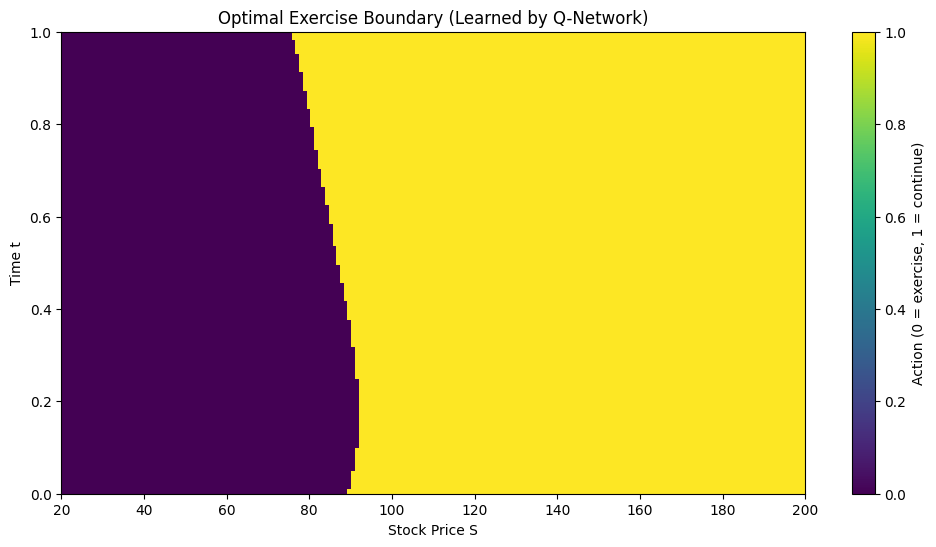

In [39]:
import matplotlib.pyplot as plt

def plot_exercise_boundary(q_network, S_min=20, S_max=200, S_steps=200):
    """
    Plots the action chosen (0=exercise, 1=continue) across a grid of stock prices and times.
    """
    S_grid = np.linspace(S_min, S_max, S_steps)
    T_grid = np.arange(N+1)

    # Matrix of actions: rows = time, cols = stock price
    action_matrix = np.zeros((N+1, S_steps))

    for t_idx in T_grid:
        for j, S in enumerate(S_grid):
            state = state_to_tensor(S, t_idx).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network(state)
                action = torch.argmax(q_vals, dim=1).item()
            action_matrix[t_idx, j] = action

    plt.figure(figsize=(12, 6))
    plt.imshow(
        action_matrix,
        extent=[S_grid.min(), S_grid.max(), 0, T],
        origin='lower',
        aspect='auto',
        cmap='viridis'
    )
    
    plt.colorbar(label="Action (0 = exercise, 1 = continue)")
    plt.xlabel("Stock Price S")
    plt.ylabel("Time t")
    plt.title("Optimal Exercise Boundary (Learned by Q-Network)")
    plt.show()
    
plot_exercise_boundary(q_net)
